In [1]:
import numpy as np
import matplotlib.pyplot as plt

共找到 3 個目標（CFAR + Peak）：
第 1 個目標: Range = 300.00 m, Velocity = 74.95 m/s, fd = 38476.56 Hz
第 2 個目標: Range = 100.00 m, Velocity = 30.06 m/s, fd = 15429.69 Hz
第 3 個目標: Range = 200.00 m, Velocity = -44.90 m/s, fd = -23046.87 Hz


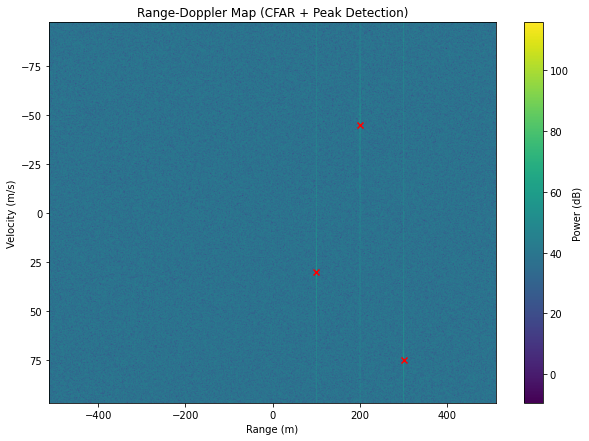

In [2]:
from scipy.ndimage import maximum_filter

# ------------------------------
# 參數設定
# ------------------------------
c = 3e8                # 光速 (m/s)
fc = 77e9              # 中心頻率 (Hz)
B = 150e6              # Bandwidth (Hz)
T_chirp = 50e-6        # Chirp時間 (sec)
slope = B / T_chirp    # Chirp斜率 (Hz/s)

N_s = 1024             # Chirp內採樣點數
N_p = 512              # Pulse數 (決定Doppler解析度)
T_p = 1e-5             # Pulse間隔 (sec)
Fs = N_s / T_chirp     # 取樣頻率

# 虛擬目標設定
target_ranges = [100, 200, 300]         # 單位: m
target_velocities = [30, -45, 75]       # 單位: m/s
target_rcs = [1, 0.8, 1.2]              # 目標反射強度

# ------------------------------
# 資料生成
# ------------------------------
t = np.arange(N_s) / Fs
rx = np.zeros((N_p, N_s), dtype=complex)

for p in range(N_p):
    for r, v, rcs in zip(target_ranges, target_velocities, target_rcs):
        tau = 2 * r / c
        fd = 2 * v * fc / c
        phase_shift = np.exp(1j * 2 * np.pi * (fd * (p * T_p) + slope * tau * t))
        rx[p, :] += rcs * phase_shift

# 加上雜訊
rx += 0.1 * (np.random.randn(N_p, N_s) + 1j * np.random.randn(N_p, N_s))

# ------------------------------
# 2D FFT處理
# ------------------------------
range_fft = np.fft.fft(rx, axis=1)
range_fft = np.fft.fftshift(range_fft, axes=1)

doppler_fft = np.fft.fft(range_fft, axis=0)
doppler_fft = np.fft.fftshift(doppler_fft, axes=0)

rd_map = 20 * np.log10(np.abs(doppler_fft) + 1e-6)  # dB scale

# ------------------------------
# Axis設定
# ------------------------------
freq_range = np.fft.fftshift(np.fft.fftfreq(N_s, d=1/Fs))
ranges = c * freq_range / (2 * slope)

freq_doppler = np.fft.fftshift(np.fft.fftfreq(N_p, d=T_p))
velocities = freq_doppler * c / (2 * fc)

# ------------------------------
# CFAR 參數
# ------------------------------
num_train = 16   # 訓練單元數
num_guard = 4   # 保護單元數
P_fa = 1e-12     # 偽警率

# 轉 dB
rd_power = np.abs(doppler_fft) ** 2

cfar_mask = np.zeros_like(rd_power, dtype=bool)

for i in range(num_guard + num_train, N_p - (num_guard + num_train)):
    for j in range(num_guard + num_train, N_s - (num_guard + num_train)):
        # 提取訓練區域（排除 guard + CUT）
        train_cells = rd_power[
            i - (num_guard + num_train): i + (num_guard + num_train) + 1,
            j - (num_guard + num_train): j + (num_guard + num_train) + 1
        ]
        train_cells = train_cells.copy()
        train_cells[
            num_train: num_train + 2 * num_guard + 1,
            num_train: num_train + 2 * num_guard + 1
        ] = 0  # 排除 CUT + Guard
        
        # 計算 CFAR threshold
        noise_level = np.sum(train_cells) / ( (2*num_train + 2*num_guard + 1)**2 - (2*num_guard + 1)**2 )
        alpha = num_train * (P_fa ** (-1/num_train) - 1)
        threshold = alpha * noise_level
        
        # 比對 CUT
        if rd_power[i, j] > threshold:
            cfar_mask[i, j] = True

# ------------------------------
# Non-Maximum Suppression
# ------------------------------
window_size = 7  # 可調，5 或 7 都行
local_max = maximum_filter(rd_power, size=window_size) == rd_power

final_mask = cfar_mask & local_max

peak_coords = np.argwhere(final_mask)
peak_coords = sorted(peak_coords, key=lambda x: rd_map[x[0], x[1]], reverse=True)

print(f"共找到 {len(peak_coords)} 個目標（CFAR + Peak）：")
for idx, (dop_idx, range_idx) in enumerate(peak_coords):
    rng = ranges[range_idx]
    vel = velocities[dop_idx]
    fd = freq_doppler[dop_idx]
    print(f"第 {idx+1} 個目標: Range = {rng:.2f} m, Velocity = {vel:.2f} m/s, fd = {fd:.2f} Hz")

# ------------------------------
# 畫圖
# ------------------------------
plt.figure(figsize=(10, 7))
plt.imshow(rd_map, extent=[ranges[0], ranges[-1], velocities[-1], velocities[0]],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Power (dB)')
plt.title('Range-Doppler Map (CFAR + Peak Detection)')
plt.xlabel('Range (m)')
plt.ylabel('Velocity (m/s)')

for dop_idx, range_idx in peak_coords:
    plt.scatter(ranges[range_idx], velocities[dop_idx], color='red', marker='x')

plt.show()